In [1]:
from paths import *
from nano_maker.nanomaker import NanoMaker
from nano_maker.container.configs import skeleton_config, naanobot_config, radial_config

In [2]:
skeleton_weight_filename = "skeleton_e3.pt"
skeleton_cfg = skeleton_config
# naanobot_weight_filename = "naano_e3.pt"
# naanobot_config = naanobot_config
radial_cfg = radial_config

In [3]:
model = NanoMaker(skeleton_weight_filename=skeleton_weight_filename,
                  skeleton_cfg=skeleton_config,
                  radial_cfg=radial_cfg)

In [17]:
drug_i_want_to_deliver = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"

In [18]:
model.ingest_chemical(drug_i_want_to_deliver)

In [19]:
nano_product = model.generate()
nano_product

[[8.979494338548506, 13.411697467416744, -1.2030313690010364],
 [11.14906793374416, 9.960300656819635, 2.3859662658048655],
 [14.546326085273556, -0.1895852361509689, 1.3499157548628917],
 [12.447862190698816, 6.52171362196923, 0.6706777683438343],
 [13.424888301998413, -1.1887301728344468, 1.8485360674433466],
 [12.890529921980514, -1.3581043022411987, 2.129385320606348],
 [12.194354352385814, 3.3407953799144208, 0.7976092190196068],
 [12.273179416978518, 2.6822887608419332, 0.7368432585553804],
 [11.499377487234835, -4.025800679342327, 0.014167745452931677],
 [11.163653966088825, -4.317861214727802, 0.060009112851417905],
 [11.236542549267352, -2.355551246624031, -0.9186516759755675],
 [8.381921153356233, -7.382882716958104, -0.7573483552275971],
 [7.957868992887264, -7.165817355403336, 2.633097376608769],
 [5.876392093222218, -8.69209329381919, 1.9561316307335141],
 [8.785982198501447, 5.309051850008912, 2.0660135158815542],
 [8.445403284094182, 4.672521116145066, 3.4256037504344663

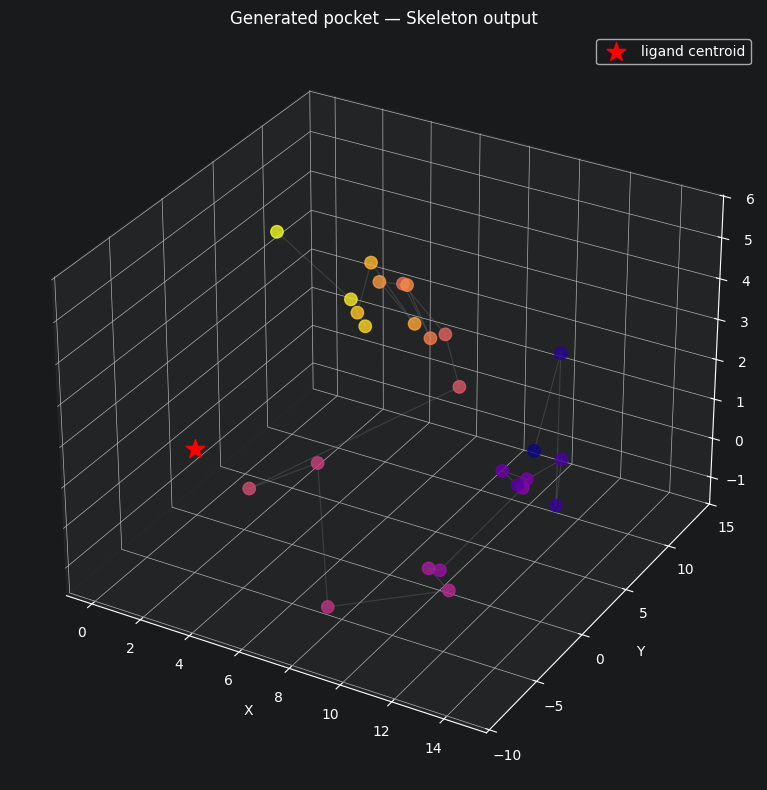

Radii (should be roughly decreasing):
  residue 1: 16.185
  residue 2: 15.139
  residue 3: 14.610
  residue 4: 14.069
  residue 5: 13.604
  residue 6: 13.136
  residue 7: 12.669
  residue 8: 12.584
  residue 9: 12.184
  residue 10: 11.970
  residue 11: 11.517
  residue 12: 11.195
  residue 13: 11.028
  residue 14: 10.673
  residue 15: 10.471
  residue 16: 10.242
  residue 17: 9.876
  residue 18: 9.739
  residue 19: 9.637
  residue 20: 9.334
  residue 21: 9.268
  residue 22: 8.858
  residue 23: 8.456
  residue 24: 7.734
  residue 25: 7.408
  residue 26: 6.485


In [29]:
# vibe coded visualizer -> will make my own

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

coords = np.array(nano_product)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# plot points colored by sequence order — early=dark, late=bright
ax.scatter(coords[:,0], coords[:,1], coords[:,2],
           c=np.linspace(0, 1, len(coords)),  # just pass the scalar values
           cmap='plasma', s=80, alpha=0.8)

# draw lines between consecutive points to see the sequence
for i in range(len(coords)-1):
    ax.plot([coords[i,0], coords[i+1,0]],
            [coords[i,1], coords[i+1,1]],
            [coords[i,2], coords[i+1,2]],
            'gray', alpha=0.3, linewidth=0.8)

# mark the origin (ligand centroid)
ax.scatter([0], [0], [0], c='red', s=200, marker='*', label='ligand centroid')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Generated pocket — Skeleton output')
ax.legend()
plt.tight_layout()
plt.show()

# also print radii to verify ordering
radii = np.linalg.norm(coords, axis=1)
print("Radii (should be roughly decreasing):")
for i, r in enumerate(radii):
    print(f"  residue {i+1}: {r:.3f}")